In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
uniprotID_geneSymbol = pd.read_excel("D:/chh/2023workProject/prottalk/database/uniprotID_geneSymbol_geneID.xlsx")
uniprotID_geneSymbol.head()

,UniprotID,GeneSymbol,GeneID
0,A0A024RBG1,NUDT4B,440672
1,A0A1B0GUA7,TEX51,101929926
2,A0AV96,RBM47,54502
3,A0AVT1,UBA6,55236
4,A0FGR8,ESYT2,57488


In [2]:
matrixB = pd.read_csv("D:/chh/2023workProject/prottalk/code/differ analysis20230822/matrix.csv", index_col= 0)
drug_cell_drugs = pd.read_excel("D:/chh/2023workProject/prottalk/database/drug_cell_inhi24_IC50_MOA_combo_20231113-1549.xlsx" )
sampleInfoB = pd.read_csv("D:/chh/2023workProject/prottalk/database/iDrug_sample_final_info20231207_NY.csv")

In [3]:
files = os.listdir("//172.16.13.136/share/members/chenghonghan/PTV1/proof_check20260608/fig2/fig2D/")
files = [i for i in files if i.endswith("csv")]
print(files)

['#35 Decitabine_2waysAnova_20231206-1857.csv', '#38 Erlotinib Hydrochloride_2waysAnova_20231206-1857.csv', '#53 Docetaxel_2waysAnova_20231206-1857.csv', '#69 Fluorouracil_2waysAnova_20231206-1857.csv', '#8 Alpelisib_2waysAnova_20231206-1857.csv', '#9 Talazoparib_2waysAnova_20231206-1857.csv']


In [8]:
for f in files:
    deptest = pd.read_csv("//172.16.13.136/share/members/chenghonghan/PTV1/proof_check20260608/fig2/fig2D/" + f, index_col=0)
    deptest = deptest[(deptest["two_way_p"] < 0.05) & (deptest["Effective_p"] < 0.05)]
    deptest = deptest.loc[deptest['genesymbol'].isin(['ATG3', 'BTF3', 'PAK1', 'NDE1', 'ELAVL2', 'CKS2'])]
    
    if deptest.shape[0] ==0:
        continue
    dd = f.replace("_2waysAnova_20231206-1857.csv", "").split(" ")[0]
    drug = f.replace("_2waysAnova_20231206-1857.csv", "").split(" ")[1]
    if "#{}".format(dd) == "#39":
        continue
    print(dd, drug)
    for index in range( deptest.shape[0]):
        proCur = deptest.index.values[index]

        Synergy = "Y"
        sample0 = list( set(sampleInfoB[ sampleInfoB["pert_time"] == 0 ]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample6_24_48_Y  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] == Synergy ) & (sampleInfoB["pert_time"]>0)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample6_24_48_N  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] != Synergy ) & (sampleInfoB["pert_time"]>0)]["Sample_ID"] ) & set(matrixB.index.values)  ) 

        temp_mat = matrixB.loc[sample0 + sample6_24_48_Y, proCur ].dropna()
        temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
        print('{} {} {} {}samples {}cells:{}'.format( proCur, uniprotID_geneSymbol[uniprotID_geneSymbol['UniprotID'] == proCur]['GeneSymbol'].values[0], 'Y', temp_info.shape[0],
        temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() ))

        temp_mat = matrixB.loc[sample0 + sample6_24_48_N, proCur ].dropna()
        temp_info = sampleInfoB[ sampleInfoB['Sample_ID'].isin(temp_mat.index) ]
        print('{} {} {} {}samples {}cells:{}'.format( proCur, uniprotID_geneSymbol[uniprotID_geneSymbol['UniprotID'] == proCur]['GeneSymbol'].values[0], 'N', temp_info.shape[0], 
        temp_info['protein_plate'].nunique(), temp_info['protein_plate'].unique() )   )
    print('\n')

#35 Decitabine
Q12926 ELAVL2 Y 382samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']
Q12926 ELAVL2 N 468samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']
Q9NT62 ATG3 Y 533samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']
Q9NT62 ATG3 N 651samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']


#38 Erlotinib
P20290 BTF3 Y 578samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 

In [ ]:
#38 Erlotinib
Q13153 PAK1 Y 529samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']
Q13153 PAK1 N 631samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']
Q9NXR1 NDE1 Y 94samples 17cells:['HCC1143' 'HS578T' 'HCC38' 'HCC1395' 'BT20' 'BT549' 'HCC1806' 'HCC1937'
 'HCC70' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436']
Q9NXR1 NDE1 N 110samples 17cells:['HCC1143' 'HS578T' 'HCC38' 'HCC1395' 'BT20' 'BT549' 'HCC1806' 'HCC1937'
 'HCC70' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436']


#53 Docetaxel
P20290 BTF3 Y 571samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']
P20290 BTF3 N 691samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-436' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'HCC1187']


#69 Fluorouracil
Q9NT62 ATG3 Y 534samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']
Q9NT62 ATG3 N 653samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']


#8 Alpelisib
P33552 CKS2 Y 81samples 9cells:['HS578T' 'HCC70' 'HCC38' 'HCC1937' 'BT549' 'HCC1395' 'BT20' 'HCC1143'
 'HCC1806']
P33552 CKS2 N 82samples 9cells:['HS578T' 'HCC70' 'HCC38' 'HCC1937' 'BT549' 'HCC1395' 'BT20' 'HCC1143'
 'HCC1806']


#9 Talazoparib
Q12926 ELAVL2 Y 388samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']
Q12926 ELAVL2 N 457samples 18cells:['HCC1143' 'HS578T' 'HCC70' 'HCC1937' 'HCC1806' 'HCC38' 'HCC1395' 'BT549'
 'BT20' 'T47D' 'MCF7' 'MDA-MB-453' 'MDA-MB-468' 'DU4475'
 'MDA-MB-453(ATCC)' 'MDA-MB-231' 'MDA-MB-436' 'HCC1187']

#35 Decitabine_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


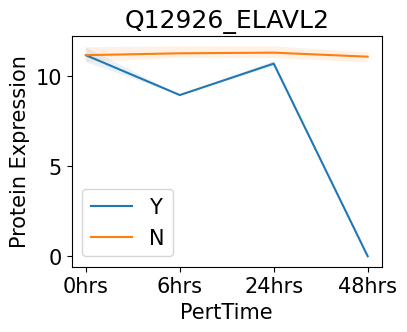

C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


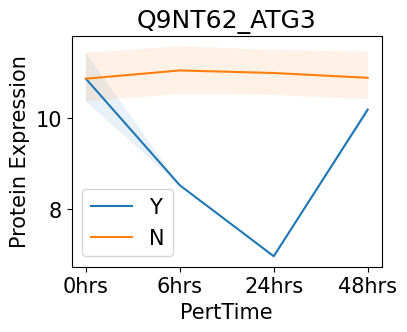

#38 Erlotinib Hydrochloride_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


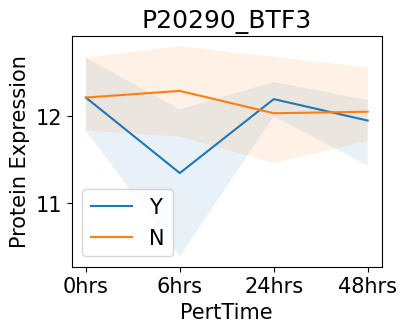

C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


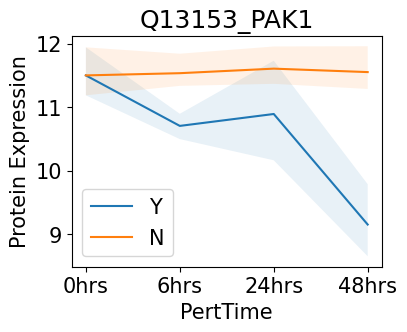

C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


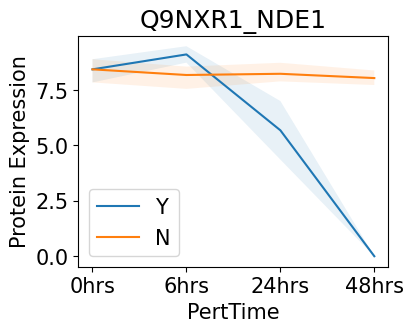

#53 Docetaxel_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


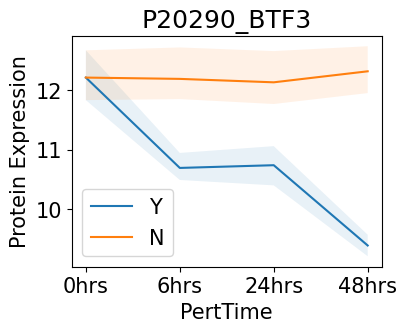

#69 Fluorouracil_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


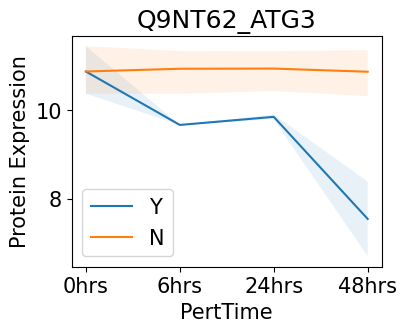

#8 Alpelisib_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


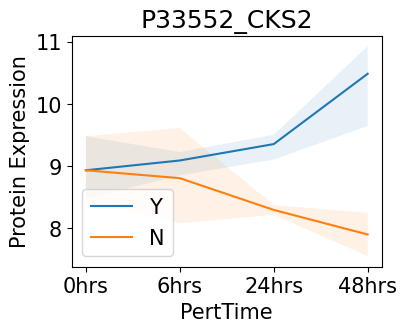

#9 Talazoparib_2waysAnova_20231206-1857.csv


C:\Users\dell\AppData\Local\Temp\ipykernel_6352\3342669800.py:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  l = deptest.loc[proCur, ][-1]


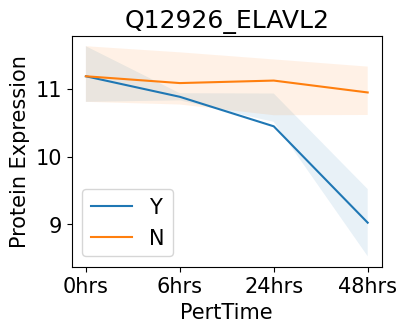

In [ ]:
for f in files:
    deptest = pd.read_csv("//172.16.13.136/share/members/chenghonghan/PTV1/proof_check20260608/fig2/fig2D/" + f, index_col=0)
    deptest = deptest[(deptest["two_way_p"] < 0.05) & (deptest["Effective_p"] < 0.05)]
    deptest = deptest.loc[deptest['genesymbol'].isin(['ATG3', 'BTF3', 'PAK1', 'NDE1', 'ELAVL2', 'CKS2'])]
    
    if deptest.shape[0] ==0:
        continue
    dd = f.replace("_2waysAnova_20231206-1857.csv", "").split(" ")[0]
    drug = f.replace("_2waysAnova_20231206-1857.csv", "").split(" ")[1]
    if "#{}".format(dd) == "#39":
        continue

    print(f)

    for index in range( deptest.shape[0]):
        plt.figure(figsize = (4, 3))
        proCur = deptest.index.values[index]

        # proCur = 'Q9NT62'

        Synergy = "Y"
        sample0 = list( set(sampleInfoB[ sampleInfoB["pert_time"] == 0 ]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample6  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] == Synergy ) & (sampleInfoB["pert_time"] == 6)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample24  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] == Synergy ) & (sampleInfoB["pert_time"] == 24)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample48  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] == Synergy ) & (sampleInfoB["pert_time"] == 48)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        matrix0 = matrixB.loc[sample0, proCur ].dropna()
        if matrix0.shape[0] == 0:
            matrix0 = np.array([0])
        matrix6 = matrixB.loc[sample6, proCur ].dropna()
        if matrix6.shape[0] == 0:
            matrix6 = np.array([0])
        matrix24 = matrixB.loc[sample24, proCur ].dropna()
        if matrix24.shape[0] == 0:
            matrix24 = np.array([0])
        matrix48 = matrixB.loc[sample48, proCur ].dropna()
        if matrix48.shape[0] == 0:
            matrix48 = np.array([0])
        y1 = [matrix0.mean() , matrix6.mean()   , matrix24.mean() , matrix48.mean()  ]
        y1 = [0 if np.isnan(val) else val for val in y1]
        x = list(range(1, 5, 1))
        plt.plot(x, y1, linestyle='-' , label= "Y") # , marker = "o"
        y2  = [ np.percentile(matrix0 , 75) , np.percentile(matrix6 , 75) , np.percentile(matrix24  , 75) , np.percentile(matrix48 , 75) ]
        y3  =  [ np.percentile(matrix0 , 25) , np.percentile(matrix6 , 25) , np.percentile(matrix24  , 25) , np.percentile(matrix48 , 25) ]
        plt.fill_between(x, y2, y3, alpha=0.1)

        sample0 = list( set(sampleInfoB[ sampleInfoB["pert_time"] == 0 ]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample6  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] != Synergy ) & (sampleInfoB["pert_time"] == 6)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample24  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] != Synergy ) & (sampleInfoB["pert_time"] == 24)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        sample48  = list( set(sampleInfoB[(sampleInfoB["pert_id"] == dd) &  (sampleInfoB["NY"] != Synergy ) & (sampleInfoB["pert_time"] == 48)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
        matrix0 = matrixB.loc[sample0, proCur ].dropna()
        if matrix0.shape[0] == 0:
            matrix0 = np.array([0])
        matrix6 = matrixB.loc[sample6, proCur ].dropna()
        if matrix6.shape[0] == 0:
            matrix6 = np.array([0])
        matrix24 = matrixB.loc[sample24, proCur ].dropna()
        if matrix24.shape[0] == 0:
            matrix24 = np.array([0])
        matrix48 = matrixB.loc[sample48, proCur ].dropna()
        if matrix48.shape[0] == 0:
            matrix48 = np.array([0])
        y1 = [matrix0.mean() , matrix6.mean()   , matrix24.mean() , matrix48.mean()  ]
        y1 = [0 if np.isnan(val) else val for val in y1]
        x = list(range(1, 5, 1))
        plt.plot(x, y1, linestyle='-' , label= "N") # , marker = "o"
        # print(x, y1)
        y2  = [ np.percentile(matrix0 , 75) , np.percentile(matrix6 , 75) , np.percentile(matrix24  , 75) , np.percentile(matrix48 , 75) ]
        y3  =  [ np.percentile(matrix0 , 25) , np.percentile(matrix6 , 25) , np.percentile(matrix24  , 25) , np.percentile(matrix48 , 25) ]
        plt.fill_between(x, y2, y3, alpha=0.1)

        plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
        plt.ylabel('Protein Expression')
        plt.xlabel('PertTime')
        l = deptest.loc[proCur, ][-1]
        plt.title( proCur + "_" + l )
        plt.legend(loc  = "lower left") # 显示label
        plt.savefig(r"//172.16.13.136/share/members/chenghonghan/PTV1/proof_check20260608/fig2/fig2D/"+dd +" " + drug + " "+ proCur + "_" + l +"_Response_line_上下四分卫.pdf", bbox_inches = 'tight')
        plt.show()
    #     break
    # break 